In [ ]:
!pip install "matplotlib==3.11.0" "pylatexenc==2.10" "qiskit==2.4.2" "qiskit-aer==0.17.2" "qiskit-algorithms==0.4.0" "qiskit-machine-learning==0.9.0" "scikit-learn==1.9.0",

## Quantum Machine Learning

QML can be understood in different way but here we will focus on how we can take classical data and use quantum circuits to learn from such data in order to perform classification tasks. The field is much more than this but getting these basic concepts will help you set a solid foundation moving forward.

### Data embedding

Quantum computers handle quantum states. So, what do I do if I only have classical data? Quantum embedding deals with this, trying to find the quantum representation of your data points. While doing this, if we can actually improve their representation so that data becomes more separable, the better.

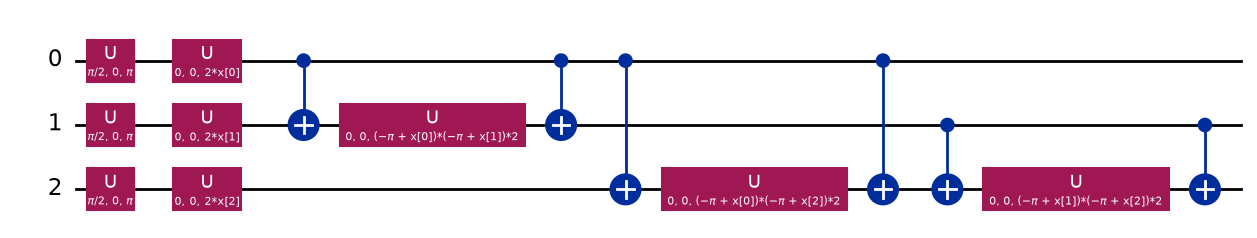

In [1]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(3, reps=1)
feature_map.decompose().draw('mpl', fold=-1)

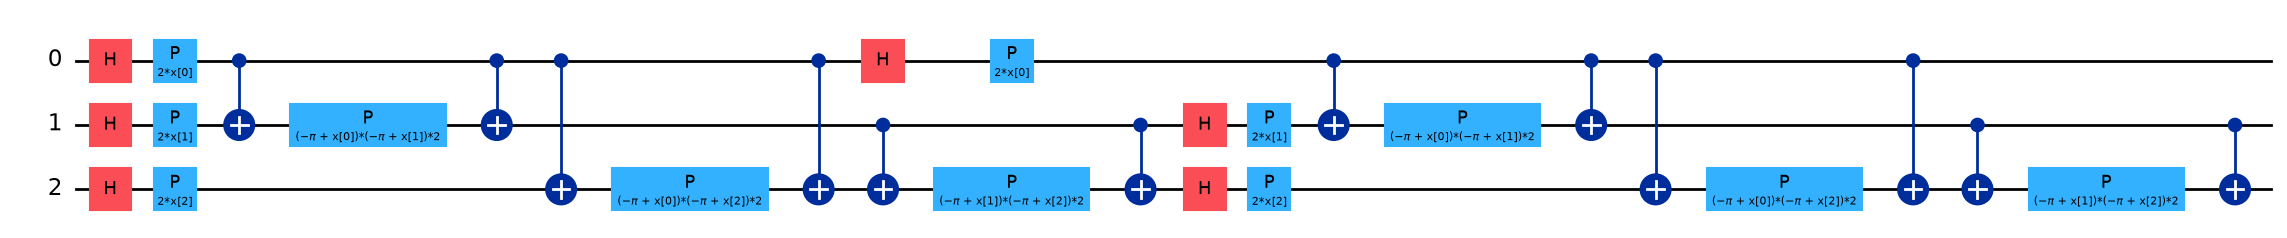

In [2]:
feature_map_2 = zz_feature_map(3, reps=2, entanglement="full")
feature_map_2.draw('mpl', fold=-1)

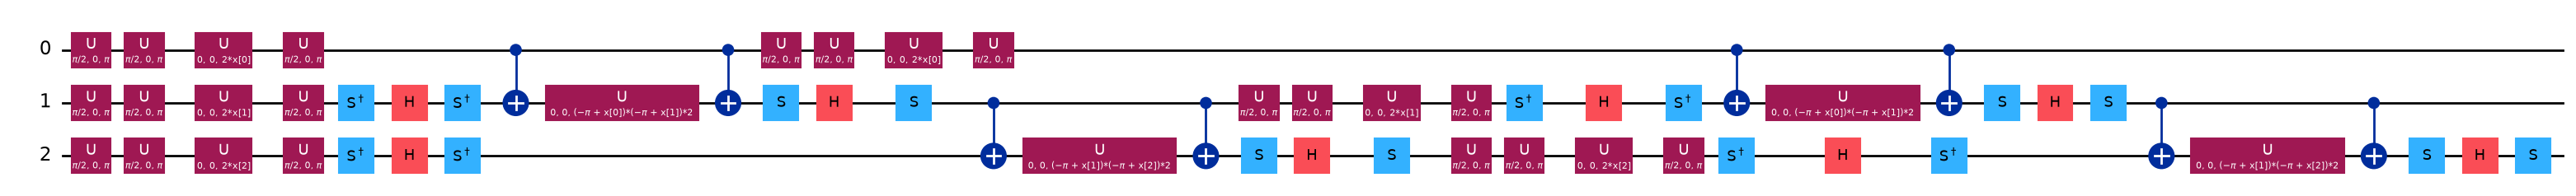

In [3]:
from qiskit.circuit.library import pauli_feature_map

feature_map_pauli = pauli_feature_map(3, paulis=["X", "YZ"], entanglement='linear')
feature_map_pauli.decompose().draw('mpl', fold=-1)

So if you have a dataset with three features (columns), it is straightforward to produce quantum states using those three values as angle rotations using this quantum embedding.

In [4]:
from qiskit import QuantumCircuit

qcirc = QuantumCircuit(3,3)
qcirc.compose(feature_map, inplace=True)
qcirc.measure([0,1,2], [0,1,2])

qcirc.draw(fold=-1, style="mpl")

┌───┐┌───────────┐                                                                                         ┌─┐                                           
q_0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■────■────────────────────────────────────■───────┤M├───────────────────────────────────────────
     ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐  │                                    │       └╥┘                                     ┌─┐   
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──┼────────────────────────────────────┼────■───╫───────────────────────────────────■──┤M├───
     ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐┌──────────────────────────────┐┌─┴─┐┌─┴─┐ ║ ┌──────────────────────────────┐┌─┴─┐└╥┘┌─┐
q_2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├┤ P((-π + x[0])*(-π + x[2])*2) ├┤ X ├┤ X ├─╫─┤ P((-π + x[1])*(-π + x[2])*2) ├┤ X ├─╫─┤M├
     └───┘└───────────┘                                          └───┘└──────────────────────────────┘└───┘└───┘ ║ └──────────────────────────────┘└───┘ ║ └╥┘
c: 3/════════════════════════════════════════════════════════════════════════════════════════════════════════════╩═══════════════════════════════════════╩══╩═
                                                                                                                 0                                       1  2

In [5]:
feature_map.parameters

ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2])])

In [6]:
circ = qcirc.assign_parameters({
    'x[0]' : 0.01,
    'x[1]' : 0.5,
    'x[2]' : 0.9,
})

In [7]:
from qiskit_aer import AerSimulator

# execute the quantum circuit
simulator = AerSimulator()

result = simulator.run(circ, shots=1000).result()
counts  = result.get_counts(circ)
print(counts)

{'110': 125, '001': 112, '101': 140, '100': 135, '111': 120, '011': 113, '000': 140, '010': 115}


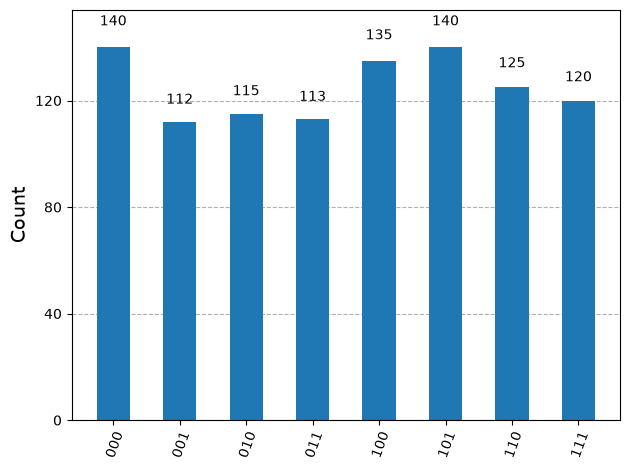

In [8]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

Where do we get those parameter values from? Let's try with some sample datasets from the [Scikit Learn library](https://scikit-learn.org/stable/).

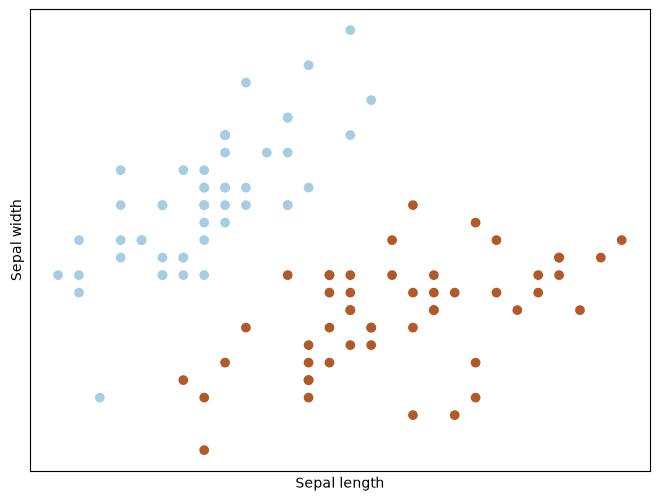

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.decomposition import PCA

# import some data to play with
iris = datasets.load_iris()
X = iris.data[:100, :2]  # we only take the first two features.
Y = iris.target[:100] # and first 100 samples

plt.figure(2, figsize=(8, 6))
plt.clf()

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.xticks(())
plt.yticks(())

plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.33,
    random_state=42,
)

scaler = MinMaxScaler((-0.9, 0.9))

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

We create a dimension appropriate feature map.

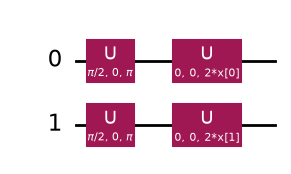

In [11]:
from qiskit.circuit.library import z_feature_map

fmap = z_feature_map(X_train.shape[1], reps=1)
fmap.decompose().draw('mpl')

## Kernels

In [12]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_aer.primitives import SamplerV2 as Sampler

# How to compute the fidelity between the states
fidelity = ComputeUncompute(sampler=Sampler())

# Feature map and quantum Kernel
kernel = FidelityQuantumKernel(feature_map=fmap, fidelity=fidelity)
kernel.evaluate(X_train[0,:], X_train[0,:])

array([[1.]])

What is this ComputeUncompute class? It creates when in machine learning is know as the **kernel trick**. This trick allos us to use a function as a measure of distance in a higher dimensional state. So, given two samples grom our dataset we could obtain

$$
K(x_i, x_j) \ge 0
$$
which for the same sample should return $K(x_i,x_i) = 0$ distance as they are the same point in the kernel dimensional space.

A quantum circuit can be viewed as the kernel function operating in a similar manner:

$$
K(x_i, x_j) = \langle\psi(x_i)|\psi(x_j)\rangle = \langle 0 |\Psi^{\dagger}(x)|\Psi(x_j)|0\rangle
$$
so that $\Psi$ is the function describing our quantum cirucit and its conjugate pefforms the operation backwards. This produces a **compute - uncompute** dynamic returning $|0\rangle$ state when operations being performed are the same in parameterized actions in both cases. When measuring fidelity as outcome, this scale is inverted 1 meaning a complete overlap for the expected outcome $|0\rangle$.

This is the key to [Quantum Support Vector Classifiers](https://iraitzm.github.io/qc-handbook/parts/qml/kernels.html#quantum-kernel)

In [13]:
kernel.evaluate(X_train[1,:], X_train[0,:])

array([[0.32226562]])

Thus, we know that samples 0 and 1 from our dataset produce quantum states that overlap just 0.35, meaning they are quite ditant in that quantum feature space without the need of observing the actual states they produce.

## Quantum Support Vector Classifier

We now can use this concept of distance trying to obatin a classical model that can create hyperplanes so that this data becomes more separable.

In [14]:
from qiskit_machine_learning.algorithms import QSVC

# QKernel + SVC
qsvc = QSVC(quantum_kernel=kernel)
qsvc.fit(X_train, y_train)
qsvc.score(X_test, y_test)

1.0

Perfect score, meaning our model can perfectly distinguish between 0 and 1 labeled samples. Well, the original information was already separable enough, don't you think? Let's try witha  harder example.

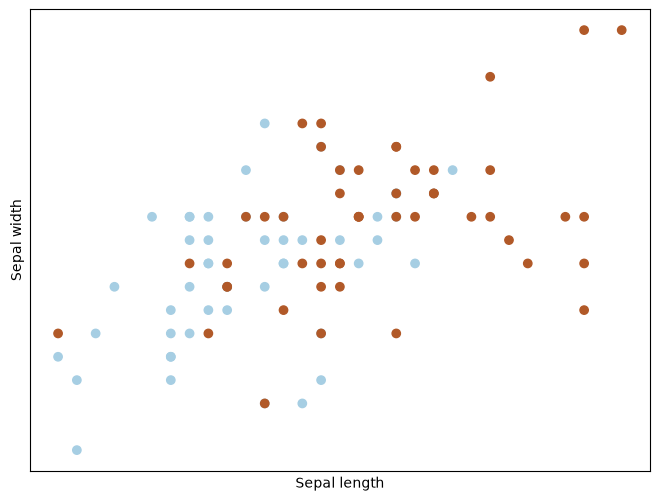

In [15]:
X_hard = iris.data[50:150, :2]  # we only take the last two features.
Y_hard = iris.target[50:] # and first 100 samples

plt.figure(2, figsize=(8, 6))
plt.clf()

# Plot the training points
plt.scatter(X_hard[:, 0], X_hard[:, 1], c=Y_hard, cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.xticks(())
plt.yticks(())

plt.show()

In [16]:
# Train and test
X_train_hard, X_test_hard, y_train_hard, y_test_hard = train_test_split(
    X_hard,
    Y_hard,
    test_size=0.33,
    random_state=42,
)

# Scale
_scaler = MinMaxScaler((-0.9, 0.9))
X_train_scl = _scaler.fit_transform(X_train_hard)
X_test_scl = _scaler.transform(X_test_hard)

# Feature map and kernel composition
fmap_h = z_feature_map(X_train_scl.shape[1], reps=1)

# Feature map and quantum Kernel
kernel_h = FidelityQuantumKernel(feature_map=fmap_h, fidelity=fidelity)

# QKernel + SVC
qsvc_h = QSVC(quantum_kernel=kernel_h)
qsvc_h.fit(X_train_scl, y_train_hard)
qsvc_h.score(X_test_scl, y_test_hard)

0.696969696969697

In [17]:
from sklearn.metrics import classification_report

y_pred = qsvc_h.predict(X_test_scl)
print(classification_report(y_test_hard, y_pred))

              precision    recall  f1-score   support

           1       0.68      0.79      0.73        19
           2       0.64      0.50      0.56        14

    accuracy                           0.67        33
   macro avg       0.66      0.64      0.65        33
weighted avg       0.66      0.67      0.66        33



### Exercise

Can you propose a different feature map (ZZ maybe?) and check if results improve?

In [ ]:
# YOUR CODE GOES HERE

## Quantum Neural Networks

QNN's take it one step further, considering we already embbed the data and maybe we could define something like an open anstaz and find the right set of parameters so that the circuit itself produces a classification over the sample being encoded. This removes the need to compare a given sample against a set of support samples, reducing the amount of execution during inference.

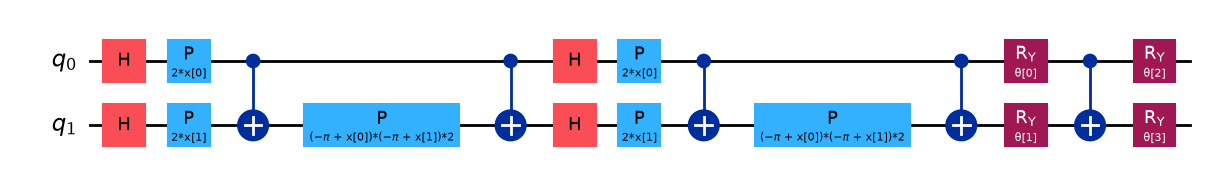

In [18]:
from qiskit.circuit.library import real_amplitudes

num_inputs = 2
feature_map_nn = zz_feature_map(num_inputs)
ansatz = real_amplitudes(num_inputs, reps=1)

# construct QNN
qnn = QuantumCircuit(num_inputs)
qnn.compose(feature_map_nn, inplace=True)
qnn.compose(ansatz, inplace=True)
qnn.draw(output="mpl")

In [19]:
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN

# We append the estructure to the Estimator primitive
estimator_qnn = EstimatorQNN(
    circuit=qnn, input_params=feature_map_nn.parameters, weight_params=ansatz.parameters
)

# construct neural network classifier
estimator_classifier = NeuralNetworkClassifier(
    estimator_qnn, optimizer=COBYLA(maxiter=60)
)

estimator_classifier.fit(X_train_scl, y_train_hard)
estimator_classifier.score(X_test_scl, y_test_hard)

0.5757575757575758

In [21]:
estimator_classifier.predict(X_test_scl[1,:])

array([[1.]])

Here, we need to get creative on defining both the feature map but also the ansatz that will allow us to improve that metric.